# 4sight Signal: Data Cleaning & Effectiveness (Detailed Analysis)

This is the **analyst's working notebook**: every quality check, every fix, and every test of the signal, step by step. A lighter, PM-facing summary lives in `pm_view.ipynb`.

**Two questions:**
1. Is the vendor's data trustworthy? (find errors, fix them, prove it)
2. Does the signal actually forecast the ETF price, and *what is it*?

All logic is imported from `analysis.py`, so these numbers match the marimo notebooks exactly.

In [1]:

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from analysis import (
    load_raw, audit, clean, characterize_signal, signal_effectiveness,
    lead_lag, split_half_ic, backtest_curves, market_model, DETREND_WINDOW,
)

C = {"price":"#334155","signal":"#0ea5e9","good":"#10b981",
     "muted":"#94a3b8","fix":"#ef4444","bench":"#f59e0b"}
plt.rcParams.update({
    "figure.figsize":(10,4.2), "figure.dpi":110, "axes.spines.top":False,
    "axes.spines.right":False, "axes.grid":True, "grid.color":"#eef2f7",
    "grid.linewidth":1, "axes.edgecolor":"#cbd5e1", "axes.labelcolor":"#334155",
    "xtick.color":"#475569","ytick.color":"#475569","axes.titlecolor":"#1e293b",
    "axes.titlesize":13, "axes.titleweight":"bold", "font.size":11,
})
pd.set_option("display.max_columns", 20); pd.set_option("display.width", 160)


## 1. Load the raw data

Daily data for a broad-market ETF (S&P 500-like) plus the vendor's `Signal`.

In [2]:
raw = load_raw()
print(f"{len(raw):,} rows  |  {raw.Date.min().date()} -> {raw.Date.max().date()}")
display(raw.head())
display(raw.describe().round(2))

1,038 rows  |  2015-11-19 -> 2020-01-06


,Date,Signal,Open,High,Low,Close,Adj Close
0,2015-11-19,13.768540,116.440002,116.650002,115.739998,116.059998,108.281601
1,2015-11-20,13.608819,116.480003,117.360001,116.379997,116.809998,108.981323
2,2015-11-23,12.990589,116.709999,117.889999,116.680000,117.389999,109.522453
3,2015-11-24,12.667435,116.879997,118.419998,116.559998,118.250000,110.324837
4,2015-11-25,13.019910,118.300003,119.320000,118.110001,119.169998,111.183159


,Date,Signal,Open,High,Low,Close,Adj Close
count,1038,1038.00,1038.00,1038.00,1038.00,1038.00,1038.00
mean,2017-12-11 17:03:48.901734,16.77,141.85,142.69,140.91,141.84,136.34
min,2015-11-19 00:00:00,0.00,94.08,95.40,93.64,94.79,-152.28
25%,2016-11-30 06:00:00,14.69,132.13,132.91,130.54,131.82,125.29
50%,2017-12-09 12:00:00,17.30,146.77,147.96,145.63,146.89,142.67
75%,2018-12-23 06:00:00,19.03,155.37,156.29,154.42,155.29,151.80
max,2020-01-06 00:00:00,35.43,172.79,173.39,171.95,196.28,168.84
std,NaN,3.10,18.48,18.47,18.40,18.50,21.43


## 2. Data-quality audit

We test for things that are **physically impossible** in a real market. These aren't judgment calls, they're violations of definitions:

| Check | Why it's impossible |
|---|---|
| `non_positive_price` | A price <= 0 can't exist. |
| `price_spike_outlier` | A ~24% one-day move in a broad ETF is a fat-finger typo. |
| `high_below_low` | The High is *below* the Low, so the range is inverted. |
| `low_above_open_close` / `high_below_open_close` | Price traded outside its own daily range. |
| `adj_close_too_high` | Adjusted close materially above the close. |

In [3]:
issues = audit(raw)
print(f"Total issues: {len(issues)}")
display(issues["check"].value_counts().rename_axis("check").reset_index(name="count"))
display(issues)

Total issues: 27


,check,count
0,low_above_open_close,16
1,high_below_open_close,4
2,adj_close_too_high,2
3,high_below_low,2
4,price_spike_outlier,2
5,non_positive_price,1


,row,date,column,check,bad_value,note
0,262,2016-12-05,Adj Close,adj_close_too_high,166.175079,"Adj Close materially above Close, unusual for ..."
1,338,2017-03-27,Adj Close,adj_close_too_high,158.577637,"Adj Close materially above Close, unusual for ..."
2,407,2017-07-04,Low,low_above_open_close,"L=141.40 > min(O,C)=141.34",Low is above the day's open/close
3,431,2017-08-07,High,high_below_open_close,"H=140.35 < max(O,C)=140.44",High is below the day's open/close
4,455,2017-09-11,Low,low_above_open_close,"L=140.23 > min(O,C)=139.11",Low is above the day's open/close
5,456,2017-09-12,Low,low_above_open_close,"L=140.82 > min(O,C)=139.11",Low is above the day's open/close
6,457,2017-09-13,Low,low_above_open_close,"L=141.32 > min(O,C)=139.11",Low is above the day's open/close
7,458,2017-09-14,Low,low_above_open_close,"L=141.42 > min(O,C)=139.11",Low is above the day's open/close
8,459,2017-09-15,Low,low_above_open_close,"L=141.55 > min(O,C)=139.11",Low is above the day's open/close
9,460,2017-09-18,Low,low_above_open_close,"L=142.60 > min(O,C)=139.11",Low is above the day's open/close


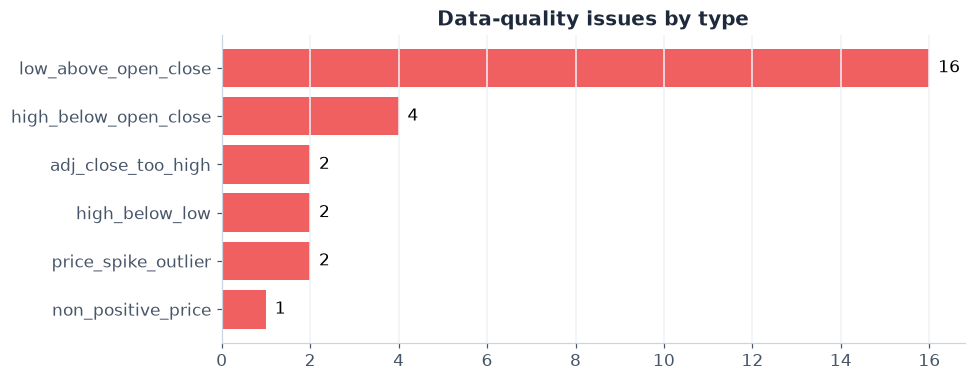

In [4]:

vc = issues["check"].value_counts()
fig, ax = plt.subplots(figsize=(9,3.6))
ax.barh(vc.index[::-1], vc.values[::-1], color=C["fix"], alpha=0.85)
ax.set_title("Data-quality issues by type"); ax.grid(axis="y")
for i,v in enumerate(vc.values[::-1]): ax.text(v+0.2, i, str(v), va="center")
plt.tight_layout(); plt.show()

## 3. Apply fixes (and prove the data is clean afterward)

Conservative, explainable corrections:
- **Impossible / fat-finger prices** -> linear interpolation from neighbours.
- **High/Low violations** -> rebuilt as the true max/min of the day's O/H/L/C.
- **Broken Adjusted Close** -> rebuilt from Close x the stable adjustment ratio.

Every change is logged: old -> new -> reason.

In [5]:
clean_df, corrections = clean(raw)
nd = corrections["row"].nunique()
print(f"{nd} days corrected, {len(corrections)} field-level fixes")
display(corrections)

24 days corrected, 28 field-level fixes


,row,date,column,old_value,new_value,reason
0,262,2016-12-05,Adj Close,166.1751,127.9182,Rebuilt as Close x median ratio (0.9607)
1,338,2017-03-27,Adj Close,158.5776,129.4457,Rebuilt as Close x median ratio (0.9607)
2,407,2017-07-04,Low,141.4000,141.3400,"Low set to min(O,H,L,C) to fix inverted/invali..."
3,431,2017-08-07,High,140.3500,140.4400,"High set to max(O,H,L,C) to fix inverted/inval..."
4,455,2017-09-11,Low,140.2300,139.1100,"Low set to min(O,H,L,C) to fix inverted/invali..."
5,456,2017-09-12,Low,140.8200,139.1100,"Low set to min(O,H,L,C) to fix inverted/invali..."
6,457,2017-09-13,Low,141.3200,139.1100,"Low set to min(O,H,L,C) to fix inverted/invali..."
7,458,2017-09-14,Low,141.4200,139.1100,"Low set to min(O,H,L,C) to fix inverted/invali..."
8,459,2017-09-15,Low,141.5500,139.1100,"Low set to min(O,H,L,C) to fix inverted/invali..."
9,460,2017-09-18,Low,142.6000,139.1100,"Low set to min(O,H,L,C) to fix inverted/invali..."


In [6]:
residual = audit(clean_df)
tag = "(spotless)" if len(residual)==0 else "(!)"
print(f"Re-audit after cleaning -> {len(residual)} remaining issues {tag}")
assert len(residual) == 0

Re-audit after cleaning -> 0 remaining issues (spotless)


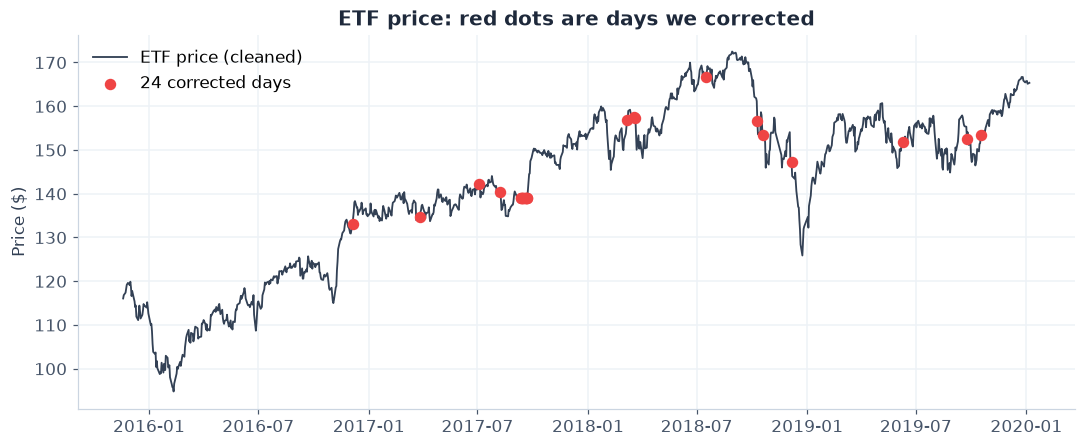

In [7]:

fix_rows = (corrections.groupby("row")
            .agg(reason=("reason","first"),
                 cols=("column", lambda s: ", ".join(sorted(set(s)))))
            .reset_index())
fix_rows["Date"]  = clean_df.loc[fix_rows["row"], "Date"].values
fix_rows["Close"] = clean_df.loc[fix_rows["row"], "Close"].values

fig, ax = plt.subplots()
ax.plot(clean_df["Date"], clean_df["Close"], color=C["price"], lw=1.2, label="ETF price (cleaned)")
ax.scatter(fix_rows["Date"], fix_rows["Close"], color=C["fix"], s=42, zorder=5,
           label=f"{len(fix_rows)} corrected days")
ax.set_title("ETF price: red dots are days we corrected")
ax.set_ylabel("Price ($)"); ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()


## 4. What *is* this signal? (reason before measuring)

The vendor says it forecasts price. We don't assume that, so we interrogate it with three hypotheses:

- **H1.** A volatility or risk gauge (VIX-like)?
- **H2.** Just a repackaging of the ETF's own price?
- **H3.** Does whatever's *left* carry independent forecasting power?

In [8]:

ch = characterize_signal(clean_df)
s = ch["shape"]
print(f"Signal shape: range {s['min']:.1f}-{s['max']:.1f}, mean {s['mean']:.1f}, std {s['std']:.1f}")
vol = pd.DataFrame([{"window (d)":w, "corr(signal, realized vol)":round(v,3)}
                    for w,v in ch["vol_corr"].items()])
print("\nH1. Volatility gauge? Correlation with realized vol:")
display(vol)
print("-> negative at every window => NOT a volatility/risk product.")

Signal shape: range 0.0-35.4, mean 16.8, std 3.1

H1. Volatility gauge? Correlation with realized vol:


,window (d),"corr(signal, realized vol)"
0,5,-0.119
1,10,-0.147
2,20,-0.176
3,30,-0.194


-> negative at every window => NOT a volatility/risk product.


In [9]:

print(f"H2. Repackaged price?  R^2(signal ~ price & MAs) = {ch['price_r2']:.3f}")
print(f"     corr(signal, price level)             = {ch['level_corr']:.3f}")
print(f"-> ~{ch['price_r2']*100:.0f}% of the signal is just the price we already own.")

H2. Repackaged price?  R^2(signal ~ price & MAs) = 0.613
     corr(signal, price level)             = 0.805
-> ~61% of the signal is just the price we already own.


In [10]:
h3 = pd.DataFrame([
    {"test":"Detrended PRICE alone (free)",      "5-day IC":round(ch["ic_detr_price"],3)},
    {"test":"Detrended SIGNAL",                  "5-day IC":round(ch["ic_detr_signal"],3)},
    {"test":"Signal RESIDUAL (non-price part)",  "5-day IC":round(ch["ic_signal_residual"],3)},
    {"test":"Residual, controlling for price",   "5-day IC":round(ch["partial_corr_resid"],3)},
])
display(h3)
display(Markdown(
    f"**H3 conclusion:** price alone does **not** forecast (IC {ch['ic_detr_price']:+.3f}, "
    f"negative), but the signal's independent part does (IC {ch['ic_signal_residual']:+.3f}, "
    f"partial corr {ch['partial_corr_resid']:+.3f}). We carve out that independent part "
    f"*walk-forward*, using only past data at each point, so it never peeks at the future. "
    f"The forecasting power is **real and independent of price**, just buried under the copied price."))


,test,5-day IC
0,Detrended PRICE alone (free),-0.106
1,Detrended SIGNAL,0.213
2,Signal RESIDUAL (non-price part),0.293
3,"Residual, controlling for price",0.286


**H3 conclusion:** price alone does **not** forecast (IC -0.106, negative), but the signal's independent part does (IC +0.293, partial corr +0.286). We carve out that independent part *walk-forward*, using only past data at each point, so it never peeks at the future. The forecasting power is **real and independent of price**, just buried under the copied price.

### H3c. Is the edge just free momentum we could build ourselves?

The obvious worry: maybe the independent part is just **trailing-return momentum**, which we get for free from the price. So we check whether plain past-return momentum forecasts the next week, and whether the signal still forecasts after we strip every momentum look-back out of it.

In [11]:
mom = pd.DataFrame([
    {"free factor": f"{w}-day momentum (past return)", "5-day IC": round(v,3)}
    for w, v in ch["mom_ic"].items()
])
display(mom)
display(Markdown(
    f"**No.** Plain past-return momentum is flat here (scores at or below zero), and after we "
    f"strip every momentum look-back out of the signal it still scores "
    f"**{ch['ic_signal_ex_momentum']:+.3f}** (it was {ch['ic_signal_with_momentum_rows']:+.3f} "
    f"before). So the edge is not repackaged momentum, the other free thing it could have been."))


,free factor,5-day IC
0,5-day momentum (past return),0.023
1,10-day momentum (past return),-0.013
2,20-day momentum (past return),-0.042


**No.** Plain past-return momentum is flat here (scores at or below zero), and after we strip every momentum look-back out of the signal it still scores **+0.257** (it was +0.213 before). So the edge is not repackaged momentum, the other free thing it could have been.

## 5. Lead-lag: does the signal *lead* the price or just react to it?

We correlate today's signal with the return *k* days away. A genuine forecaster is strongest at **k > 0** (the future). If it's strongest at k <= 0, it's coincident or lagging, so it only tells us what already happened.

,lag_k,kind,corr_raw,corr_detr
0,-5,past (react),0.0189,0.0577
1,-3,past (react),0.0280,0.0755
2,-1,past (react),0.0285,0.0766
3,0,same-day,0.0264,0.0811
4,1,future (predict),0.0149,0.0662
5,3,future (predict),0.0362,0.1157
6,5,future (predict),0.0101,0.0806


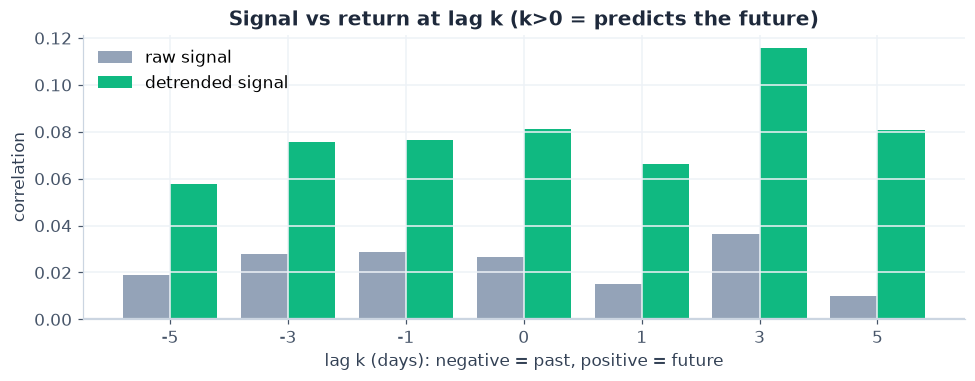

Raw signal (grey) is flat in every direction: it is mostly a copy of today's price.
Detrended signal (green) peaks in the FUTURE at k=+3 days, so there is genuine lead,
but it also lights up on the past side, so it is partly riding what just happened too.
The forward edge is real; it just isn't the whole picture.


In [12]:
ll = lead_lag(clean_df)
display(ll.round(4))
fig, ax = plt.subplots(figsize=(9,3.6))
x = np.arange(len(ll)); w = 0.4
ax.bar(x - w/2, ll["corr_raw"],  w, label="raw signal",       color=C["muted"])
ax.bar(x + w/2, ll["corr_detr"], w, label="detrended signal", color=C["good"])
ax.axhline(0, color="#cbd5e1")
ax.set_xticks(x); ax.set_xticklabels(ll["lag_k"].astype(str))
ax.set_title("Signal vs return at lag k (k>0 = predicts the future)")
ax.set_xlabel("lag k (days): negative = past, positive = future"); ax.set_ylabel("correlation")
ax.legend(frameon=False); plt.tight_layout(); plt.show()
peak = int(ll.loc[ll["corr_detr"].idxmax(), "lag_k"])
print("Raw signal (grey) is flat in every direction: it is mostly a copy of today's price.")
print(f"Detrended signal (green) peaks in the FUTURE at k=+{peak} days, so there is genuine lead,")
print("but it also lights up on the past side, so it is partly riding what just happened too.")
print("The forward edge is real; it just isn't the whole picture.")


## 6. Forecasting power: the Information Coefficient

It is just how closely the signal today lines up with the ETF's return over the next *N* days. Around 0 = coin flip, around 0.05 = usable, around 0.20 = strong. We compare the **raw** signal against the **detrended** signal (copied price removed).

In [13]:

eff = signal_effectiveness(clean_df)
raw_ic  = pd.DataFrame([{"horizon (d)":h, "pearson":round(v["pearson"],4),
                         "spearman":round(v["spearman"],4), "hit_rate":round(v["hit_rate"],3)}
                        for h,v in eff["ic"].items()])
detr_ic = pd.DataFrame([{"horizon (d)":h, "pearson":round(v["pearson"],4),
                         "spearman":round(v["spearman"],4)} for h,v in eff["ic_detr"].items()])
print("RAW signal IC:");       display(raw_ic)
print("DETRENDED signal IC:"); display(detr_ic)

RAW signal IC:


,horizon (d),pearson,spearman,hit_rate
0,1,0.0149,0.0266,0.521
1,5,0.0393,0.0511,0.517
2,10,-0.0146,0.0136,0.505
3,20,-0.1062,-0.0990,0.482


DETRENDED signal IC:


,horizon (d),pearson,spearman
0,1,0.0662,0.1315
1,5,0.2131,0.2020
2,10,0.1677,0.1633
3,20,0.0800,0.0200


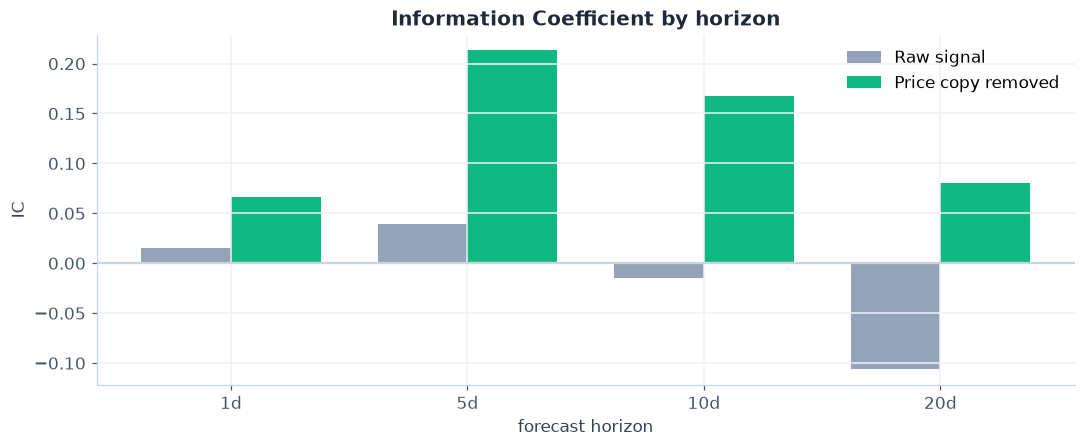

In [14]:

hz = list(eff["ic"].keys()); x = np.arange(len(hz)); w = 0.38
fig, ax = plt.subplots()
ax.bar(x-w/2, [eff["ic"][h]["pearson"] for h in hz], w, label="Raw signal", color=C["muted"])
ax.bar(x+w/2, [eff["ic_detr"][h]["pearson"] for h in hz], w, label="Price copy removed", color=C["good"])
ax.axhline(0, color="#cbd5e1"); ax.set_xticks(x); ax.set_xticklabels([f"{h}d" for h in hz])
ax.set_title("Information Coefficient by horizon"); ax.set_ylabel("IC")
ax.set_xlabel("forecast horizon"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()


## 7. Robustness: does the edge survive on data it wasn't tuned on?

A signal that only works in one stretch of history is a fluke. We split the timeline in half and re-measure the detrended score in each half.

In [15]:
rob = pd.DataFrame([split_half_ic(clean_df, horizon=h) for h in (5,10)])
display(rob.round(3))
h5 = rob[rob["horizon"]==5].iloc[0]
print("Positive in BOTH halves at the 1-2 week horizon, so the edge is real, not a one-off.")
print(f"But it is NOT evenly spread: the 5-day score is {h5['first_half']:+.3f} in the first half")
print(f"and {h5['second_half']:+.3f} in the second. Most of the measured edge sits in the back half.")
print("Enough to call the effect real, not enough to call it rock-steady. One more reason to want")
print("a longer, fresh out-of-sample stretch before trusting it with real money.")


,horizon,first_half,second_half,full,n
0,5,0.087,0.282,0.213,974
1,10,0.018,0.274,0.168,969


Positive in BOTH halves at the 1-2 week horizon, so the edge is real, not a one-off.
But it is NOT evenly spread: the 5-day score is +0.087 in the first half
and +0.282 in the second. Most of the measured edge sits in the back half.
Enough to call the effect real, not enough to call it rock-steady. One more reason to want
a longer, fresh out-of-sample stretch before trusting it with real money.


## 8. A simple backtest (with the honest caveat)

Hold the ETF when the detrended signal is positive, else cash. No leverage or shorts.

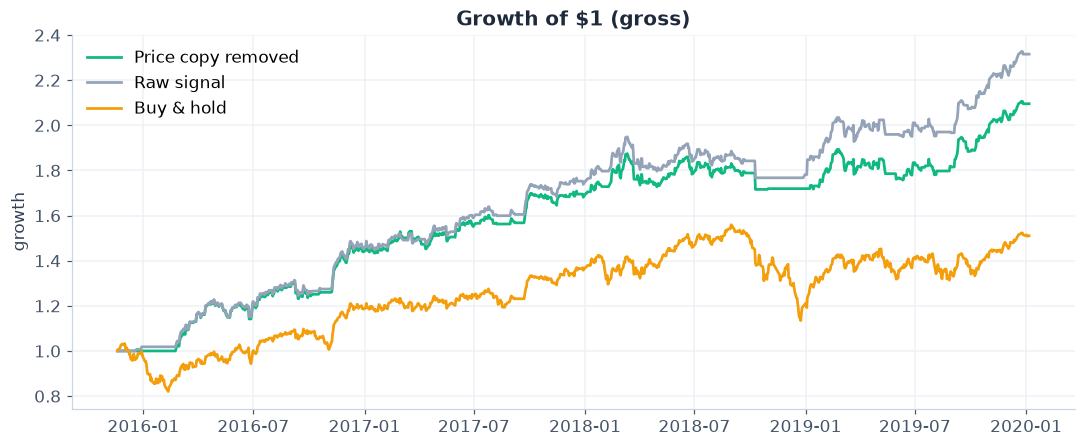

,strategy,annual gross,annual net,vol,Sharpe gross,Sharpe net,flips/yr
0,Detrended signal,19.7%,15.0%,11.2%,1.75,1.34,79
1,Raw signal,22.6%,18.1%,11.3%,2.00,1.61,74
2,Buy & hold,10.5%,10.5%,16.4%,0.64,0.64,0


**Costs are not optional.** The detrended rule flips in and out about **79 times a year**, and at a conservative **5 bps per flip** its Sharpe drops from **1.75 gross to 1.34 net**. Push the cost higher and the edge thins out fast, so this is a real input to pin down. Also note the raw strategy's high Sharpe is not skill: it is just being long in a market that only went up. The detrended rule is the one earning its return from actual signal.

In [16]:
# equity curves come straight from the engine (analysis.backtest_curves) so the
# chart and the stats table below can never use different position logic.
curves = backtest_curves(clean_df)
cols = {"Price copy removed":C["good"],"Raw signal":C["muted"],"Buy & hold":C["bench"]}
fig, ax = plt.subplots()
for k in ["Price copy removed","Raw signal","Buy & hold"]:
    ax.plot(curves["Date"], curves[k], label=k, color=cols[k], lw=1.8)
ax.set_title("Growth of $1 (gross)"); ax.set_ylabel("growth"); ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

bt = eff["backtest"]; cost = bt["cost_bps"]
def _row(name, key):
    s = bt[key]
    return {"strategy":name,
            "annual gross": f"{s['annual_return']*100:.1f}%",
            "annual net":   f"{s['annual_return_net']*100:.1f}%",
            "vol":          f"{s['vol']*100:.1f}%",
            "Sharpe gross": round(s["sharpe"],2),
            "Sharpe net":   round(s["sharpe_net"],2),
            "flips/yr":     round(s["turnover_per_yr"])}
display(pd.DataFrame([
    _row("Detrended signal", "detrended_signal_strategy"),
    _row("Raw signal", "raw_signal_strategy"),
    _row("Buy & hold", "buy_and_hold"),
]))
ds = bt["detrended_signal_strategy"]
display(Markdown(
    f"**Costs are not optional.** The detrended rule flips in and out about "
    f"**{round(ds['turnover_per_yr'])} times a year**, and at a conservative **{cost:.0f} bps "
    f"per flip** its Sharpe drops from **{ds['sharpe']:.2f} gross to {ds['sharpe_net']:.2f} net**. "
    f"Push the cost higher and the edge thins out fast, so this is a real input to pin down. "
    f"Also note the raw strategy's high Sharpe is not skill: it is just being long in a market "
    f"that only went up. The detrended rule is the one earning its return from actual signal."))


> **Caveat:** the Sharpe figures above are net of a naive 5 bps-per-flip cost, and they fall further if costs are higher, because the rule trades a lot. On top of that, this sample is a single, mostly-up market (2015 to 2020), and the edge is stronger in the back half than the front. A strong backtest over one bull run is *encouraging, not proof*. The believable evidence is the independent score that survives a price and a momentum control. The decisive test is running this beside our own signals through a drawdown.

## 9. Is the Sharpe real skill, or just less market?

Our rule sits in cash about 40% of the time, so it carries less risk than buy-and-hold by default. Maybe the whole Sharpe is just *that*. The classic check: regress the strategy's daily return on the ETF's own return. The slope (**beta**) is how much market it really holds; the intercept (**alpha**) is what's left after accounting for that exposure, the genuine timing part.

In [17]:
mm = market_model(clean_df)
display(pd.DataFrame([
    {"measure":"Alpha (per year)",                         "value":f"{mm['alpha_annual']*100:.1f}%"},
    {"measure":"Market beta",                              "value":f"{mm['beta_mkt']:.2f}"},
    {"measure":"Alpha t-stat (plain)",                     "value":f"{mm['alpha_t_ols']:.2f}"},
    {"measure":f"Alpha t-stat (Newey-West, {mm['nw_lags']}-lag)", "value":f"{mm['alpha_t_nw']:.2f}"},
    {"measure":"Strategy vol vs market vol",               "value":f"{mm['strat_vol']*100:.0f}% vs {mm['mkt_vol']*100:.0f}%"},
]))
display(Markdown(
    f"**Beta is {mm['beta_mkt']:.2f}** (well below 1), so the strategy does hold less market than "
    f"buy-and-hold, and some of the smoother ride is just that. But there is still "
    f"**{mm['alpha_annual']*100:.1f}% a year of alpha** on top, with a t-stat of about "
    f"{mm['alpha_t_nw']:.1f}. So it is **not just sitting in cash**: there is real timing skill left "
    f"over after the lower exposure. In-sample on one bull path, so suggestive, not proof, and it "
    f"does not replace the decisive test against the signals we already own."))


,measure,value
0,Alpha (per year),9.7%
1,Market beta,0.47
2,Alpha t-stat (plain),2.29
3,"Alpha t-stat (Newey-West, 5-lag)",2.11
4,Strategy vol vs market vol,11% vs 16%


**Beta is 0.47** (well below 1), so the strategy does hold less market than buy-and-hold, and some of the smoother ride is just that. But there is still **9.7% a year of alpha** on top, with a t-stat of about 2.1. So it is **not just sitting in cash**: there is real timing skill left over after the lower exposure. In-sample on one bull path, so suggestive, not proof, and it does not replace the decisive test against the signals we already own.

## Bottom line

1. **Data:** not clean. 24 impossible days, all fixed and logged, and it re-audits to zero.
2. **Identity:** not a vol gauge. About 60% of the signal is just the ETF's own price.
3. **Raw signal:** forecasts like a coin flip (the copied price drowns it).
4. **Real signal:** the independent ~40% forecasts (score about 0.2 to 0.3), positive in both halves though stronger in the back half, and neither price nor past-return momentum can replicate it for free.
5. **Costs:** the toy strategy trades a lot, so a 5 bps-per-flip cost already pulls the net Sharpe down to about 1.3. Tradable, but not the paper number.
6. **Not just de-risking:** the strategy's Sharpe isn't only from holding less market. After accounting for its market beta (about 0.47), there's still roughly 10%/yr of timing alpha, t-stat near 2 (in-sample, one path).
7. **Verdict:** believable, not plug-and-play. Don't buy yet. Get a longer history and test whether it adds anything new on top of our existing signals. See `email_to_PM.md`.
